<a href="https://colab.research.google.com/github/santiagovillamizarjaimes-collab/Primer-corte/blob/main/semana10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ejemplos con base de datos reales**

In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving f_capitulos.csv to f_capitulos.csv


In [14]:
import io
f_capitulos1 = io.BytesIO(uploaded['f_capitulos.csv'])
f_capitulos1 = pd.read_csv(f_capitulos1, sep = ",", encoding="latin-1")
f_capitulos1.head(4)

,F_01,F_01_CUAL,F_02,F_02_CUAL,F_03,F_04,F_05,F_06,F_07,F_08,...,F_18,F_19,F_20,F_20_CUAL,F_21,F_21_CUAL,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN
0,2,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1,2
1,2,NaN,2,NaN,1,18.0,3.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,1
2,2,NaN,2,NaN,1,20.0,3.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1,1
3,2,NaN,2,NaN,1,20.0,3.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1,1


In [16]:
tabla_alcohol = pd.DataFrame({
    'edad': f_capitulos1['F_04'],
    'borrachera': f_capitulos1['F_09'],
    'cerveza': f_capitulos1['F_10_A'],
    'recordar': f_capitulos1['F_19'],
    "preocupacion": f_capitulos1["F_21"]
    })
tabla_alcohol.head(5)

,edad,borrachera,cerveza,recordar,preocupacion
0,NaN,NaN,NaN,NaN,NaN
1,18.0,NaN,NaN,NaN,NaN
2,20.0,NaN,NaN,NaN,NaN
3,20.0,NaN,NaN,NaN,NaN
4,20.0,NaN,NaN,NaN,NaN


In [17]:
tabla_alcohol['cerveza'] = tabla_alcohol['cerveza'].fillna(0)
tabla_alcohol.head(5)

,edad,borrachera,cerveza,recordar,preocupacion
0,NaN,NaN,0.0,NaN,NaN
1,18.0,NaN,0.0,NaN,NaN
2,20.0,NaN,0.0,NaN,NaN
3,20.0,NaN,0.0,NaN,NaN
4,20.0,NaN,0.0,NaN,NaN


In [18]:
tabla_alcohol['borrachera'] = tabla_alcohol['borrachera'].fillna(0)
tabla_alcohol.head(5)

tabla_alcohol['recordar'] = tabla_alcohol['recordar'].fillna(0) # 0 lo tomaremos para quienes no consumen alcohol
tabla_alcohol.head(5)

tabla_alcohol['preocupacion'] = tabla_alcohol['preocupacion'].fillna(2)
tabla_alcohol.head(5)

,edad,borrachera,cerveza,recordar,preocupacion
0,NaN,0.0,0.0,0.0,2.0
1,18.0,0.0,0.0,0.0,2.0
2,20.0,0.0,0.0,0.0,2.0
3,20.0,0.0,0.0,0.0,2.0
4,20.0,0.0,0.0,0.0,2.0


In [19]:
tabla_alcohol1 = tabla_alcohol.dropna()
tabla_alcohol1.head(5)

,edad,borrachera,cerveza,recordar,preocupacion
1,18.0,0.0,0.0,0.0,2.0
2,20.0,0.0,0.0,0.0,2.0
3,20.0,0.0,0.0,0.0,2.0
4,20.0,0.0,0.0,0.0,2.0
5,16.0,0.0,3.0,1.0,2.0


In [20]:
tabla_alcohol1['cerveza'] = tabla_alcohol1['cerveza'].astype(str)
tabla_alcohol1['recordar'] = tabla_alcohol1['recordar'].astype(str)
tabla_alcohol1['preocupacion'] = tabla_alcohol1['preocupacion'].astype(str)

/tmp/ipykernel_8953/320438244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_alcohol1['cerveza'] = tabla_alcohol1['cerveza'].astype(str)
/tmp/ipykernel_8953/320438244.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_alcohol1['recordar'] = tabla_alcohol1['recordar'].astype(str)
/tmp/ipykernel_8953/320438244.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [ ]:
tabla_alcohol1 =

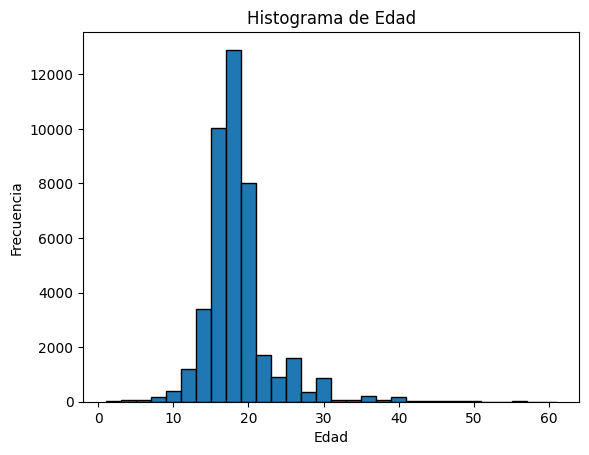

In [29]:
import matplotlib.pyplot as plt

# Crear el histograma
plt.hist(tabla_alcohol['edad'], bins= 30, edgecolor='black')

# Agregar títulos y etiquetas
plt.title('Histograma de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

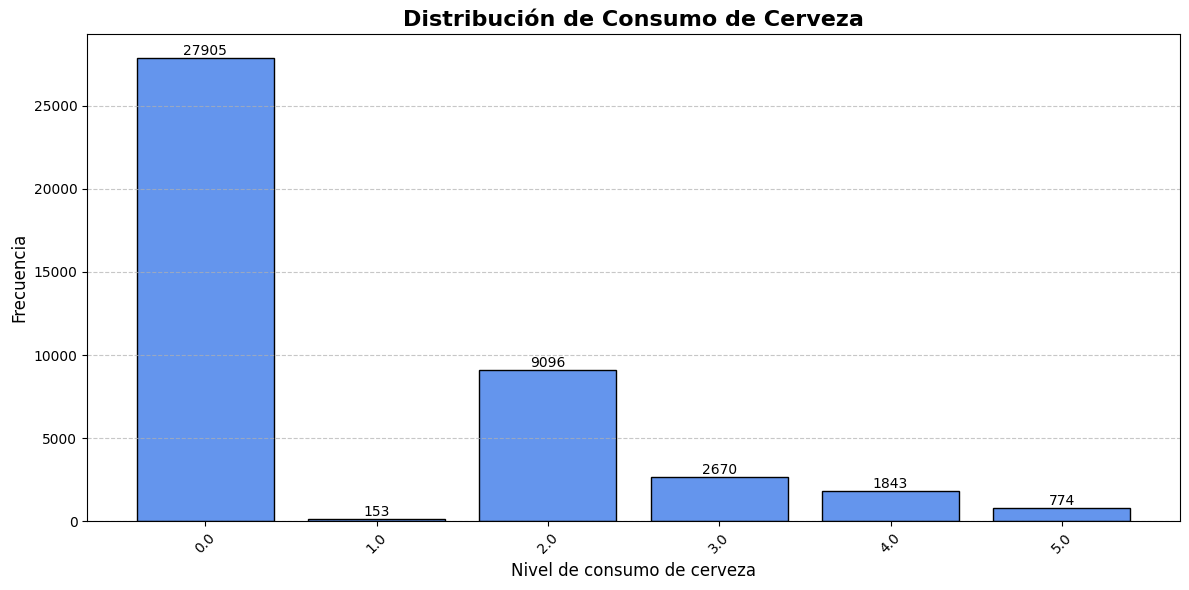

In [30]:
import matplotlib.pyplot as plt

# Contar frecuencias de la variable
frecuencias = tabla_alcohol1['cerveza'].value_counts().sort_index()

# Crear figura más grande
plt.figure(figsize=(12,6))

# Crear diagrama de barras
barras = plt.bar(frecuencias.index, frecuencias.values,
                 color='cornflowerblue', edgecolor='black')

# Añadir valores encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

# Títulos y etiquetas
plt.title('Distribución de Consumo de Cerveza', fontsize=16, fontweight='bold')
plt.xlabel('Nivel de consumo de cerveza', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Mejorar visualización
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustar márgenes
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [31]:
dataf = pd.get_dummies(tabla_alcohol1, columns=['cerveza'], prefix='cerveza')
dataf.head()

,edad,borrachera,recordar,preocupacion,cerveza_0.0,cerveza_1.0,cerveza_2.0,cerveza_3.0,cerveza_4.0,cerveza_5.0
1,18.0,0.0,0.0,2.0,True,False,False,False,False,False
2,20.0,0.0,0.0,2.0,True,False,False,False,False,False
3,20.0,0.0,0.0,2.0,True,False,False,False,False,False
4,20.0,0.0,0.0,2.0,True,False,False,False,False,False
5,16.0,0.0,1.0,2.0,False,False,False,True,False,False


In [32]:
dataf['cerveza_0.0'] = dataf['cerveza_0.0'].astype(int)
dataf['cerveza_1.0'] = dataf['cerveza_1.0'].astype(int)
dataf['cerveza_2.0'] = dataf['cerveza_2.0'].astype(int)
dataf['cerveza_3.0'] = dataf['cerveza_3.0'].astype(int)
dataf['cerveza_4.0'] = dataf['cerveza_4.0'].astype(int)
dataf['cerveza_5.0'] = dataf['cerveza_5.0'].astype(int)
dataf.head(4)

,edad,borrachera,recordar,preocupacion,cerveza_0.0,cerveza_1.0,cerveza_2.0,cerveza_3.0,cerveza_4.0,cerveza_5.0
1,18.0,0.0,0.0,2.0,1,0,0,0,0,0
2,20.0,0.0,0.0,2.0,1,0,0,0,0,0
3,20.0,0.0,0.0,2.0,1,0,0,0,0,0
4,20.0,0.0,0.0,2.0,1,0,0,0,0,0
